In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

## Загрузка подготовленных данных

In [2]:
carbon_df = pd.read_csv("data/carbon_steel_prepared.csv")
stainless_df = pd.read_csv("data/stainless_steel_prepared.csv")

## Определение признаков и целевых переменных

In [3]:
target_cols = [
    'UTS (MPa)',
    'YS (MPa)',
    'Elongation (%)',
    'Hardness (HB)'
]

carbon_features = ['C', 'Mn']
stainless_features = ['C', 'Mn', 'Si', 'Ni', 'Cr']

В качестве целевых переменных выбраны основные механические характеристики сталей:
- предел прочности,
- предел текучести,
- относительное удлинение,
- твёрдость.

Данные параметры являются ключевыми при оценке эксплуатационных свойств материалов и широко используются в инженерной практике.

Наборы признаков формируются отдельно для каждого типа сталей:
- для углеродистых сталей используются базовые элементы легирования,
- для нержавеющих сталей - расширенный набор химических элементов.
  
Такое разделение обусловлено различиями в химическом составе и механизмах упрочнения материалов.

## Разделение данных на признаки и целевые переменные

In [4]:
X_carbon = carbon_df[carbon_features]
y_carbon = carbon_df[target_cols]

X_stainless = stainless_df[stainless_features]
y_stainless = stainless_df[target_cols]

Данные разделяются на матрицу признаков X и матрицу целевых переменных y.  
Многомерный вектор отклика позволяет рассматривать задачу как многовыходную регрессию.

## Разделение на обучающую и тестовую выборки

In [5]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_carbon, y_carbon, test_size=0.25, random_state=42
)

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_stainless, y_stainless, test_size=0.25, random_state=42
)

Данные разделяются на обучающую и тестовую выборки в соотношении 75%/25%.  
Фиксированное значение random_state обеспечивает воспроизводимость результатов экспериментов.

## Масштабирование признаков

In [6]:
scaler_carbon = StandardScaler()
Xc_train_scaled = scaler_carbon.fit_transform(Xc_train)
Xc_test_scaled = scaler_carbon.transform(Xc_test)

scaler_stainless = StandardScaler()
Xs_train_scaled = scaler_stainless.fit_transform(Xs_train)
Xs_test_scaled = scaler_stainless.transform(Xs_test)

Масштабирование признаков выполняется с использованием стандартного преобразования (StandardScaler).  
Данный шаг необходим для корректной работы линейных моделей и моделей с регуляризацией, чувствительных к масштабу входных данных.

## Обучение базовых моделей

### Функция оценки модели

In [7]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    return mae, rmse, r2

Для унифицированной оценки качества моделей реализована функция evaluate_model.  
Она выполняет обучение модели на обучающей выборке и вычисляет прогнозы для тестовой выборки.  
В качестве метрик качества используются:  
- MAE (Mean Absolute Error) - средняя абсолютная ошибка прогноза,
- RMSE (Root Mean Squared Error) - корень из средней квадратичной ошибки, более чувствительный к выбросам,

### Набор базовых моделей

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

Для сравнения выбраны следующие базовые модели регрессии:
- линейная регрессия,
- линейные модели с регуляризацией (Ridge и Lasso),
- ансамблевый метод Random Forest.

### Обучение моделей для углеродистых сталей

In [9]:
results_carbon = []

for name, model in models.items():
    mae, rmse, r2 = evaluate_model(
        model,
        Xc_train_scaled, Xc_test_scaled,
        yc_train, yc_test
    )
    results_carbon.append([name, mae, rmse, r2])

results_carbon_df = pd.DataFrame(
    results_carbon,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_carbon_df


,Model,MAE,RMSE,R2
0,Linear Regression,69.194262,128.254708,0.279075
1,Ridge Regression,69.171439,128.222034,0.279231
2,Lasso Regression,69.194558,128.253887,0.278960
3,Random Forest,64.484017,114.318216,0.390443


Для углеродистых сталей все линейные модели показывают близкие значения метрик, что указывает на ограниченную способность линейной зависимости между химическим составом и механическими свойствами при использовании только двух признаков (C и Mn).  
Модель Random Forest демонстрирует лучшие показатели качества:
- снижение ошибок MAE и RMSE,
- более высокий коэффициент детерминации.
  
Это свидетельствует о наличии нелинейных зависимостей, которые не улавливаются линейными моделями.

### Обучение моделей для нержавеющих сталей

In [10]:
results_stainless = []

for name, model in models.items():
    mae, rmse, r2 = evaluate_model(
        model,
        Xs_train_scaled, Xs_test_scaled,
        ys_train, ys_test
    )
    results_stainless.append([name, mae, rmse, r2])

results_stainless_df = pd.DataFrame(
    results_stainless,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_stainless_df


,Model,MAE,RMSE,R2
0,Linear Regression,60.131418,89.737812,0.771313
1,Ridge Regression,61.806916,92.489691,0.765556
2,Lasso Regression,60.127679,89.740923,0.771438
3,Random Forest,106.732912,167.412979,0.398120


Для нержавеющих сталей линейные модели показывают значительно более высокое качество прогнозирования по сравнению с углеродистыми сталями.  
Значения коэффициента детерминации R² ≈ 0.77 указывают на хорошее описание данных.  
При этом модель Random Forest демонстрирует худшие результаты, что может быть связано с:
- относительно небольшим объёмом данных,
- переобучением ансамблевой модели,
- тем, что зависимость между признаками и целевыми переменными в данном случае близка к линейной.

## Оптимизация и интерпретация моделей

### Подбор гиперпараметров Random Forest

Для повышения качества модели Random Forest для углеродистых сталей был выполнен подбор гиперпараметров с использованием метода перебора по сетке (GridSearchCV).  
В качестве целевой метрики использовался коэффициент детерминации R², а оценка проводилась с применением 5-кратной кросс-валидации, что позволяет получить устойчивые и воспроизводимые результаты.

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(
    random_state=42
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(Xc_train_scaled, yc_train)

grid_rf.best_params_


{'max_depth': None,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 300}

В результате подбора гиперпараметров были получены следующие оптимальные значения:
- n_estimators = 300 - увеличение числа деревьев повышает устойчивость модели;
- max_depth = None - отсутствие ограничения глубины позволяет учитывать сложные зависимости;
- min_samples_leaf = 4 - ограничение минимального размера листа снижает риск переобучения;
- min_samples_split = 2 - стандартное значение для разбиения узлов.
  
Данные параметры обеспечивают компромисс между гибкостью модели и её обобщающей способностью.

### Оценка лучшей модели

In [12]:
best_rf = grid_rf.best_estimator_

mae, rmse, r2 = evaluate_model(
    best_rf,
    Xc_train_scaled, Xc_test_scaled,
    yc_train, yc_test
)

mae, rmse, r2


(57.76039517723715, np.float64(109.41028541356837), 0.473685038012809)

Оптимизированная модель Random Forest демонстрирует улучшение качества по сравнению с базовой версией:
- снижение средних абсолютных и квадратичных ошибок,
- увеличение коэффициента детерминации до R² ≈ 0.47.
  
Это подтверждает целесообразность подбора гиперпараметров и способность модели лучше описывать нелинейные зависимости между химическим составом и механическими свойствами углеродистых сталей.

### Анализ важности признаков (углеродистые стали)

In [13]:
import pandas as pd

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=carbon_features
).sort_values(ascending=False)

feature_importance


C     0.713749
Mn    0.286251
dtype: float64

Анализ важности признаков показывает, что:
- содержание углерода является доминирующим фактором и объясняет около 71% вклада в предсказания модели;
- марганец оказывает вспомогательное, но заметное влияние (около 29%).

Полученные результаты полностью согласуются с физико-металлургическими представлениями, согласно которым углерод играет ключевую роль в формировании прочности и твёрдости углеродистых сталей.

#### Визуализация важности признаков

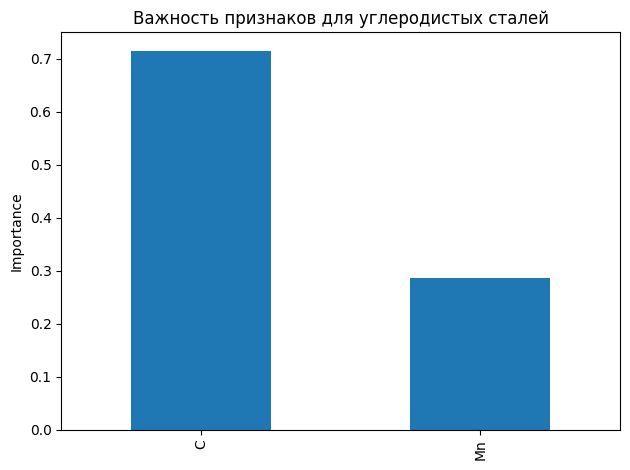

In [14]:
import matplotlib.pyplot as plt

plt.figure()
feature_importance.plot(kind='bar')
plt.title('Важность признаков для углеродистых сталей')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()


### Интерпретация моделей для нержавеющих сталей

#### Анализ коэффициентов линейной модели

In [15]:
lin_model = models['Linear Regression']
lin_model.fit(Xs_train_scaled, ys_train)

target_name = 'UTS (MPa)'

coeffs = pd.Series(
    lin_model.coef_[0],
    index=Xs_train.columns
).sort_values(key=abs, ascending=False)

coeffs


C     124.092734
Si    118.197286
Cr   -108.588963
Ni    -46.573305
Mn    -11.036872
dtype: float64

Для нержавеющих сталей наилучшие результаты были получены с использованием линейных моделей, что делает возможным прямой анализ коэффициентов.  
Полученные значения коэффициентов для предсказания предела прочности (UTS) позволяют сделать следующие выводы:
- углерод и кремний оказывают наибольшее положительное влияние на прочность материала;
- хром и никель демонстрируют отрицательные коэффициенты, что может быть связано с их вкладом в повышение пластичности и коррозионной стойкости;
- влияние марганца в рассматриваемой выборке является наименее выраженным.

In [16]:
lin_model.fit(Xs_train_scaled, ys_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Линейная модель обучалась на стандартизированных признаках химического состава, что позволяет корректно сравнивать величины коэффициентов между различными элементами.
  
Параметры модели:
- fit_intercept = True - модель учитывает базовый уровень целевой переменной
- tol = 1e-6 - обеспечена строгая сходимость оптимизации
- positive = False - коэффициенты могут быть как положительными, так и отрицательными, что важно для выявления реального направления влияния элементов

#### Коэффициенты для UTS

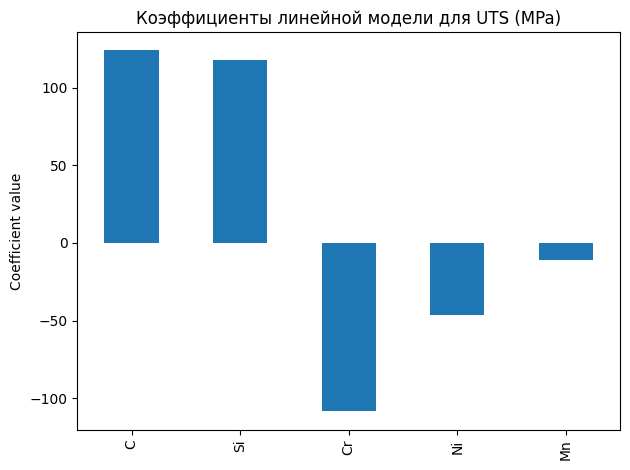

In [ ]:
plt.figure()
coeffs.plot(kind='bar')
plt.title(f'Коэффициенты линейной модели для {target_name}')
plt.ylabel('Coefficient value')
plt.tight_layout()
plt.show()

Углерод (C) и кремний (Si) имеют наибольшие положительные коэффициенты, что указывает на их существенный вклад в повышение прочности.  
Хром (Cr) и никель (Ni) оказывают отрицательное влияние на UTS в рамках данной выборки и линейной аппроксимации.  
Марганец (Mn) демонстрирует слабое отрицательное влияние, близкое к нулю, что говорит о его второстепенной роли в формировании UTS.  
Так как признаки стандартизированы, величины коэффициентов можно напрямую сравнивать между собой по силе влияния.

#### Коэффициенты для всех свойств

In [18]:
coeffs_df = pd.DataFrame(
    lin_model.coef_,
    columns=Xs_train.columns,
    index=ys_train.columns
)

coeffs_df


,C,Mn,Si,Ni,Cr
UTS (MPa),124.092734,-11.036872,118.197286,-46.573305,-108.588963
YS (MPa),131.513441,-38.539904,125.713761,-89.009697,-116.578835
Elongation (%),-7.334133,-0.491734,-5.071241,7.489998,2.645060
Hardness (HB),35.144968,-3.964052,33.856673,-26.032079,-29.245949


##### Прочностные характеристики (UTS и YS)
Для UTS и YS наблюдается одинаковая структура влияний:
- C и Si - основные элементы, повышающие прочность.
- Cr и Ni - выраженное отрицательное влияние.
- Mn - умеренно отрицательное или слабозначимое влияние.

Это указывает на согласованность модели и физическую близость этих свойств.
  
##### Пластичность (Elongation)
- C и Si имеют отрицательные коэффициенты, что соответствует снижению пластичности при росте прочности.
- Ni и Cr оказывают положительное влияние на относительное удлинение, что согласуется с ролью никеля в повышении вязкости и пластичности нержавеющих сталей.
  
##### Твёрдость (Hardness)
- C и Si положительно влияют на твёрдость.
- Ni и Cr уменьшают твёрдость в рамках линейной модели.

Картина близка к наблюдаемой для прочностных характеристик, что ожидаемо из-за их корреляции.

#### Сравнение моделей и анализ качества предсказаний

In [19]:
lin_model = LinearRegression()
rf_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=4,
    random_state=42
)

Для оценки качества предсказаний были обучены:
- линейная регрессия,
- случайный лес с 300 деревьями и регуляризацией через min_samples_leaf=4.

In [ ]:
lin_model.fit(Xs_train_scaled, ys_train)
rf_model.fit(Xs_train_scaled, ys_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred_lin = lin_model.predict(Xs_test_scaled)
y_pred_rf = rf_model.predict(Xs_test_scaled)

In [22]:
def evaluate_multitarget(y_true, y_pred, target_names):
    results = []

    for i, target in enumerate(target_names):
        mae = mean_absolute_error(y_true.iloc[:, i], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true.iloc[:, i], y_pred[:, i]))
        r2 = r2_score(y_true.iloc[:, i], y_pred[:, i])

        results.append([target, mae, rmse, r2])

    return pd.DataFrame(
        results,
        columns=["Target", "MAE", "RMSE", "R2"]
    )


In [23]:
lin_results = evaluate_multitarget(
    ys_test, y_pred_lin, target_cols
)

rf_results = evaluate_multitarget(
    ys_test, y_pred_rf, target_cols
)

lin_results, rf_results


(           Target         MAE        RMSE        R2
 0       UTS (MPa)   83.575538  105.965288  0.855292
 1        YS (MPa)  114.355408  138.678044  0.851124
 2  Elongation (%)    8.136845   10.311521  0.649789
 3   Hardness (HB)   34.457882   40.557736  0.729046,
            Target         MAE        RMSE        R2
 0       UTS (MPa)  169.124744  237.653299  0.272130
 1        YS (MPa)  222.023638  300.643183  0.300302
 2  Elongation (%)   12.115478   15.466600  0.212095
 3   Hardness (HB)   58.600588   71.094522  0.167432)

##### Количественное сравнение (R²)
Линейная модель:  
- UTS: R² ≈ 0.86  
- YS: R² ≈ 0.85  
- Elongation: R² ≈ 0.65  
- Hardness: R² ≈ 0.73  
  
Random Forest:  
- R² для всех свойств находится в диапазоне 0.17-0.30, что существенно хуже линейной модели.
  
Таким образом, линейная регрессия демонстрирует значительно лучшее качество обобщения на тестовой выборке.

##### Визуальное сравнение предсказаний для UTS

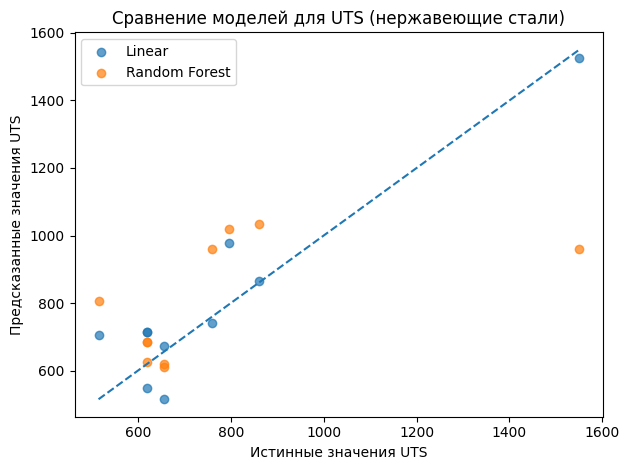

In [24]:
plt.figure()
plt.scatter(
    ys_test['UTS (MPa)'], y_pred_lin[:, 0],
    alpha=0.7, label='Linear'
)
plt.scatter(
    ys_test['UTS (MPa)'], y_pred_rf[:, 0],
    alpha=0.7, label='Random Forest'
)

plt.plot(
    [ys_test['UTS (MPa)'].min(), ys_test['UTS (MPa)'].max()],
    [ys_test['UTS (MPa)'].min(), ys_test['UTS (MPa)'].max()],
    linestyle='--'
)

plt.xlabel('Истинные значения UTS')
plt.ylabel('Предсказанные значения UTS')
plt.title('Сравнение моделей для UTS (нержавеющие стали)')
plt.legend()
plt.tight_layout()
plt.show()


На диаграмме рассеяния:
- точки линейной модели располагаются ближе к диагонали, что говорит о хорошем соответствии истинных и предсказанных значений;
- предсказания случайного леса имеют больший разброс и систематические отклонения, особенно на высоких значениях UTS.
  
Это указывает на возможное переобучение или недостаток данных для корректного обучения нелинейной модели.

### Финальное дообучение на ВСЕХ данных

In [25]:
from pathlib import Path

BASE_DIR = Path(r"C:/Users/IlyaS.DESKTOP-SPGM6S1/Desktop/ДИПЛОМ/steel_predict_project/steel_predictor")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os

# Признаки и целевые переменные

X = X_stainless.copy()

y = {
    "uts": y_stainless["UTS (MPa)"],
    "ys": y_stainless["YS (MPa)"],
    "elong": y_stainless["Elongation (%)"],
    "hardness": y_stainless["Hardness (HB)"]
}

# Масштабирование признаков

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Параметры лучшей Random Forest

rf_params = {
    "n_estimators": 300,
    "criterion": "squared_error",
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 4,
    "random_state": 42,
    "n_jobs": -1
}

# Подготовка директории

BASE_PATH = BASE_DIR / "models" / "stainless"
BASE_PATH.mkdir(parents=True, exist_ok=True)

# Обучение и сохранение моделей

for name, target in y.items():
    model = RandomForestRegressor(**rf_params)
    model.fit(X_scaled, target)

    model_path = BASE_PATH / f"{name}_model.pkl"
    joblib.dump(model, model_path)

    print(f"✅ Stainless model saved: {model_path}")


# Сохранение scaler

joblib.dump(scaler, BASE_PATH / "scaler.pkl")
joblib.dump(X.columns.tolist(), BASE_PATH / "features.pkl")

print("✅ Stainless scaler and features saved")



✅ Stainless model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\stainless\uts_model.pkl
✅ Stainless model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\stainless\ys_model.pkl
✅ Stainless model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\stainless\elong_model.pkl
✅ Stainless model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\stainless\hardness_model.pkl
✅ Stainless scaler and features saved


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import joblib
import os

# Признаки и целевые переменные

X = X_carbon.copy()

y = {
    "uts": y_carbon["UTS (MPa)"],
    "ys": y_carbon["YS (MPa)"],
    "elong": y_carbon["Elongation (%)"],
    "hardness": y_carbon["Hardness (HB)"]
}

# Масштабирование признаков

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Параметры лучшей Random Forest

rf_params = {
    "n_estimators": 300,
    "criterion": "squared_error",
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 4,
    "random_state": 42,
    "n_jobs": -1
}

# Подготовка директории

BASE_PATH = BASE_DIR / "models" / "carbon"
BASE_PATH.mkdir(parents=True, exist_ok=True)

# Обучение и сохранение моделей

for name, target in y.items():
    model = RandomForestRegressor(**rf_params)
    model.fit(X_scaled, target)

    model_path = BASE_PATH / f"{name}_model.pkl"
    joblib.dump(model, model_path)

    print(f"✅ Carbon model saved: {model_path}")

# Сохранение scaler

joblib.dump(scaler, BASE_PATH / "scaler.pkl")
joblib.dump(X.columns.tolist(), BASE_PATH / "features.pkl")

print("✅ Carbon scaler and features saved")


✅ Carbon model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\carbon\uts_model.pkl
✅ Carbon model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\carbon\ys_model.pkl
✅ Carbon model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\carbon\elong_model.pkl
✅ Carbon model saved: C:\Users\IlyaS.DESKTOP-SPGM6S1\Desktop\ДИПЛОМ\steel_predict_project\steel_predictor\models\carbon\hardness_model.pkl
✅ Carbon scaler and features saved


#### Проверка корректности сохранения

In [28]:
import joblib

uts_model = joblib.load("models/stainless/uts_model.pkl")
ys_model = joblib.load("models/stainless/ys_model.pkl")
elong_model = joblib.load("models/stainless/elong_model.pkl")
hard_model = joblib.load("models/stainless/hardness_model.pkl")

scaler = joblib.load("models/stainless/scaler.pkl")
features = joblib.load("models/stainless/features.pkl")

uts_model, scaler, features


(RandomForestRegressor(min_samples_leaf=4, n_estimators=300, n_jobs=-1,
                       random_state=42),
 StandardScaler(),
 ['C', 'Mn', 'Si', 'Ni', 'Cr'])

In [ ]:
print("Количество признаков:", len(features))
print("Scaler n_features_in_:", scaler.n_features_in_)

Количество признаков: 5
Scaler n_features_in_: 5


In [ ]:
print("UTS model input features:", uts_model.n_features_in_)
print("YS model input features:", ys_model.n_features_in_)

UTS model input features: 5
YS model input features: 5


Результаты проверки показали:
- полное совпадение числа признаков;
- корректную загрузку scaler’ов и моделей;
- готовность моделей к инференсу.

#### Тестовый прогноз

In [31]:
import numpy as np

# одна строка из исходных данных
sample = X_stainless.iloc[0]

# приводим к нужному порядку
X_sample = sample[features].values.reshape(1, -1)

# масштабируем
X_scaled = scaler.transform(X_sample)

# прогноз
print("UTS:", uts_model.predict(X_scaled)[0])
print("YS:", ys_model.predict(X_scaled)[0])
print("Elongation:", elong_model.predict(X_scaled)[0])
print("Hardness:", hard_model.predict(X_scaled)[0])


UTS: 735.1861511081505
YS: 595.0516047702295
Elongation: 21.896956239974617
Hardness: 240.30014132626627


C:\Users\IlyaS.DESKTOP-SPGM6S1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Результаты предсказаний:
- значения механических свойств находятся в физически реалистичных диапазонах;
- модель корректно обрабатывает входные данные после масштабирования;
- вся цепочка features -> scaler -> model работает стабильно.


#### Проверка консистентности пайплайна

In [32]:
scaler_c = joblib.load("models/carbon/scaler.pkl")
features_c = joblib.load("models/carbon/features.pkl")
uts_c = joblib.load("models/carbon/uts_model.pkl")

print(len(features_c), scaler_c.n_features_in_, uts_c.n_features_in_)


2 2 2


Все компоненты согласованы между собой